# Model 1: Latent Dirichlet Allocation (LDA)

This notebook applies LDA topic modeling to the preprocessed 20 Newsgroups dataset. LDA is a probabilistic model that discovers hidden topics by analyzing word co-occurrence patterns across documents. I use coherence scores to select the optimal number of topics and Optuna for hyperparameter tuning.

**Input**: `s3://topic-modeling-demo/02_preprocessing/newsgroups_preprocessed.parquet`  
**Output**: Visualizations saved to `./output/`, model saved to `./output/lda_model.pkl`

## Imports

In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm

try:
    import gensim
    from gensim import corpora
    from gensim.models import LdaMulticore, CoherenceModel
except:
    ! pip install gensim
    import gensim
    from gensim import corpora
    from gensim.models import LdaMulticore, CoherenceModel
    
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    !pip install optuna -q
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    from wordcloud import WordCloud
except ImportError:
    !pip install wordcloud -q
    from wordcloud import WordCloud

print('All imports successful')

All imports successful


## Helper Class

In [2]:
class LDATopicModel:
    """LDA topic modeling with coherence-based evaluation."""
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.s3_client = boto3.client('s3', region_name='us-east-1')
        self.df_data = None
        self.lst_texts = None
        self.dictionary = None
        self.corpus = None
        self.lda_model = None
        self.int_best_num_topics = None
        self.set_plot_style()
    
    def set_plot_style(self):
        """Configure matplotlib/seaborn styling."""
        sns.set_style('whitegrid')
        plt.rcParams['figure.figsize'] = (14, 6)
        plt.rcParams['font.size'] = 11
    
    def import_data(self):
        """Load preprocessed data from S3."""
        str_uri = f's3://{self.str_bucket}/02_preprocessing/newsgroups_preprocessed.parquet'
        self.df_data = pd.read_parquet(str_uri)
        print(f'Loaded {len(self.df_data):,} posts from S3')
    
    def prepare_corpus(self):
        """Tokenize text and build gensim dictionary and corpus."""
        # tokenize cleaned text
        self.lst_texts = [str_doc.split() for str_doc in self.df_data['text_clean']]
        
        # build dictionary
        self.dictionary = corpora.Dictionary(self.lst_texts)
        
        # filter extremes: remove words appearing in fewer than 15 docs or more than 50% of docs
        self.dictionary.filter_extremes(no_below=15, no_above=0.5)
        
        # create bag-of-words corpus
        self.corpus = [self.dictionary.doc2bow(lst_text) for lst_text in self.lst_texts]
        
        print(f'Vocabulary size: {len(self.dictionary):,}')
        print(f'Corpus size: {len(self.corpus):,} documents')
    
    def find_optimal_topics(self, int_min_topics=5, int_max_topics=30, int_step=5):
        """Evaluate coherence scores across different topic counts."""
        lst_topic_counts = list(range(int_min_topics, int_max_topics + 1, int_step))
        lst_coherence_scores = []
        
        print(f'\nEvaluating topic counts: {lst_topic_counts}')
        for int_num_topics in tqdm(lst_topic_counts, desc='Finding optimal topics'):
            lda_model = LdaMulticore(
                corpus=self.corpus,
                id2word=self.dictionary,
                num_topics=int_num_topics,
                random_state=42,
                passes=5,
                per_word_topics=True,
                workers=3
            )
            coherence_model = CoherenceModel(
                model=lda_model,
                texts=self.lst_texts,
                dictionary=self.dictionary,
                coherence='c_v'
            )
            flt_coherence = coherence_model.get_coherence()
            lst_coherence_scores.append(flt_coherence)
            print(f'  Topics: {int_num_topics:2d} | Coherence: {flt_coherence:.4f}')
        
        # find best number of topics
        int_best_idx = np.argmax(lst_coherence_scores)
        self.int_best_num_topics = lst_topic_counts[int_best_idx]
        print(f'\nBest number of topics: {self.int_best_num_topics} (coherence: {lst_coherence_scores[int_best_idx]:.4f})')
        
        return lst_topic_counts, lst_coherence_scores
    
    def plot_coherence_scores(self, lst_topic_counts, lst_coherence_scores):
        """Plot coherence score vs number of topics."""
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(lst_topic_counts, lst_coherence_scores, 'o-', color='steelblue',
                linewidth=2, markersize=8)
        
        # highlight best
        int_best_idx = np.argmax(lst_coherence_scores)
        ax.plot(lst_topic_counts[int_best_idx], lst_coherence_scores[int_best_idx],
                'o', color='red', markersize=14, zorder=5,
                label=f'Best: {lst_topic_counts[int_best_idx]} topics')
        
        ax.set_xlabel('Number of Topics', fontsize=12, fontweight='bold')
        ax.set_ylabel('Coherence Score (c_v)', fontsize=12, fontweight='bold')
        ax.set_title('Topic Coherence vs. Number of Topics', fontsize=14, fontweight='bold')
        ax.legend(fontsize=12)
        
        for int_i, (int_x, flt_y) in enumerate(zip(lst_topic_counts, lst_coherence_scores)):
            ax.annotate(f'{flt_y:.3f}', (int_x, flt_y), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/01_coherence_scores.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 01_coherence_scores.png')
    
    def tune_hyperparameters(self, int_n_trials=10):
        """Use Optuna to tune LDA hyperparameters."""
        print(f'\nTuning hyperparameters with {int_n_trials} Optuna trials...')
        pbar = tqdm(total=int_n_trials, desc='Optuna tuning')
        
        def objective(trial):
            flt_alpha_val = trial.suggest_float('alpha', 0.01, 1.0, log=True)
            flt_eta_val = trial.suggest_float('eta', 0.01, 1.0, log=True)
            int_passes = trial.suggest_int('passes', 3, 8)
            
            lda_model = LdaMulticore(
                corpus=self.corpus,
                id2word=self.dictionary,
                num_topics=self.int_best_num_topics,
                alpha=flt_alpha_val,
                eta=flt_eta_val,
                passes=int_passes,
                random_state=42,
                per_word_topics=True,
                workers=3
            )
            coherence_model = CoherenceModel(
                model=lda_model,
                texts=self.lst_texts,
                dictionary=self.dictionary,
                coherence='c_v'
            )
            flt_coherence = coherence_model.get_coherence()
            pbar.update(1)
            pbar.set_postfix({'coherence': f'{flt_coherence:.4f}'})
            return flt_coherence
        
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=int_n_trials)
        pbar.close()
        
        print(f'\nBest trial:')
        print(f'  Coherence: {study.best_trial.value:.4f}')
        print(f'  Params: {study.best_trial.params}')
        
        return study.best_trial.params
    
    def train_final_model(self, dict_params):
        """Train the final LDA model with tuned hyperparameters."""
        print(f'\nTraining final LDA model with {self.int_best_num_topics} topics...')
        self.lda_model = LdaMulticore(
            corpus=self.corpus,
            id2word=self.dictionary,
            num_topics=self.int_best_num_topics,
            alpha=dict_params['alpha'],
            eta=dict_params['eta'],
            passes=dict_params['passes'],
            random_state=42,
            per_word_topics=True,
            workers=3
        )
        
        # compute final coherence
        coherence_model = CoherenceModel(
            model=self.lda_model,
            texts=self.lst_texts,
            dictionary=self.dictionary,
            coherence='c_v'
        )
        flt_coherence = coherence_model.get_coherence()
        print(f'Final model coherence (c_v): {flt_coherence:.4f}')
    
    def plot_top_words_per_topic(self, int_n_words=10):
        """Plot top words for each topic as horizontal bar charts."""
        int_n_topics = self.lda_model.num_topics
        int_cols = 4
        int_rows = (int_n_topics + int_cols - 1) // int_cols
        
        fig, axes = plt.subplots(int_rows, int_cols, figsize=(20, 4 * int_rows))
        axes = axes.flatten()
        
        for int_i in range(int_n_topics):
            lst_topic_words = self.lda_model.show_topic(int_i, topn=int_n_words)
            lst_words = [str_w for str_w, _ in lst_topic_words]
            lst_weights = [flt_w for _, flt_w in lst_topic_words]
            
            axes[int_i].barh(range(len(lst_words)), lst_weights,
                             color='steelblue', edgecolor='black')
            axes[int_i].set_yticks(range(len(lst_words)))
            axes[int_i].set_yticklabels(lst_words)
            axes[int_i].invert_yaxis()
            axes[int_i].set_title(f'Topic {int_i + 1}', fontsize=12, fontweight='bold')
            axes[int_i].set_xlabel('Weight', fontsize=10)
        
        # hide unused subplots
        for int_j in range(int_n_topics, len(axes)):
            axes[int_j].set_visible(False)
        
        plt.suptitle('Top Words per LDA Topic', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/02_top_words_per_topic.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 02_top_words_per_topic.png')
    
    def plot_word_clouds(self):
        """Generate word clouds for each topic."""
        int_n_topics = self.lda_model.num_topics
        int_cols = 4
        int_rows = (int_n_topics + int_cols - 1) // int_cols
        
        fig, axes = plt.subplots(int_rows, int_cols, figsize=(20, 4 * int_rows))
        axes = axes.flatten()
        
        for int_i in range(int_n_topics):
            dict_topic_words = dict(self.lda_model.show_topic(int_i, topn=30))
            wordcloud = WordCloud(
                width=400, height=300,
                background_color='white',
                colormap='viridis',
                max_words=30
            ).generate_from_frequencies(dict_topic_words)
            
            axes[int_i].imshow(wordcloud, interpolation='bilinear')
            axes[int_i].set_title(f'Topic {int_i + 1}', fontsize=12, fontweight='bold')
            axes[int_i].axis('off')
        
        for int_j in range(int_n_topics, len(axes)):
            axes[int_j].set_visible(False)
        
        plt.suptitle('Word Clouds per LDA Topic', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/03_word_clouds.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 03_word_clouds.png')
    
    def plot_topic_distribution(self):
        """Plot distribution of dominant topics across documents."""
        lst_dominant_topics = []
        for int_i, lst_bow in enumerate(self.corpus):
            lst_topic_probs = self.lda_model.get_document_topics(lst_bow)
            if lst_topic_probs:
                int_dominant = max(lst_topic_probs, key=lambda x: x[1])[0]
                lst_dominant_topics.append(int_dominant)
        
        fig, ax = plt.subplots(figsize=(14, 6))
        dict_counts = pd.Series(lst_dominant_topics).value_counts().sort_index()
        dict_counts.index = [f'Topic {int_i + 1}' for int_i in dict_counts.index]
        
        dict_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_xlabel('Topic', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Documents', fontsize=12, fontweight='bold')
        ax.set_title('Document Count by Dominant LDA Topic', fontsize=14, fontweight='bold')
        ax.set_xticklabels(dict_counts.index, rotation=45, ha='right')
        
        for int_i, int_v in enumerate(dict_counts.values):
            ax.text(int_i, int_v + max(dict_counts.values)*0.01, str(int_v),
                    ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/04_topic_distribution.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 04_topic_distribution.png')
    
    def plot_topic_heatmap(self):
        """Plot topic-term heatmap for top words."""
        int_n_words = 8
        int_n_topics = self.lda_model.num_topics
        
        # collect all unique top words
        set_all_words = set()
        for int_i in range(int_n_topics):
            lst_topic_words = self.lda_model.show_topic(int_i, topn=int_n_words)
            for str_w, _ in lst_topic_words:
                set_all_words.add(str_w)
        
        lst_all_words = sorted(set_all_words)
        
        # build matrix
        arr_matrix = np.zeros((int_n_topics, len(lst_all_words)))
        for int_i in range(int_n_topics):
            dict_topic = dict(self.lda_model.show_topic(int_i, topn=int_n_words))
            for int_j, str_w in enumerate(lst_all_words):
                arr_matrix[int_i, int_j] = dict_topic.get(str_w, 0)
        
        fig, ax = plt.subplots(figsize=(max(18, len(lst_all_words) * 0.4), int_n_topics * 0.6 + 2))
        sns.heatmap(arr_matrix, xticklabels=lst_all_words,
                    yticklabels=[f'Topic {int_i + 1}' for int_i in range(int_n_topics)],
                    cmap='YlOrRd', ax=ax, linewidths=0.5)
        ax.set_title('Topic-Word Weight Heatmap (LDA)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Words', fontsize=12, fontweight='bold')
        ax.set_ylabel('Topics', fontsize=12, fontweight='bold')
        plt.xticks(rotation=90, fontsize=8)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/05_topic_heatmap.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 05_topic_heatmap.png')
    
    def save_model(self):
        """Save the LDA model, dictionary, and corpus locally."""
        dict_model_data = {
            'lda_model': self.lda_model,
            'dictionary': self.dictionary,
            'int_best_num_topics': self.int_best_num_topics
        }
        str_model_path = f'{self.str_dirname_output}/lda_model.pkl'
        with open(str_model_path, 'wb') as f:
            pickle.dump(dict_model_data, f)
        print(f'Model saved to {str_model_path}')
    
    def print_topics(self):
        """Print all topics with their top words."""
        print('\n' + '='*60)
        print('LDA TOPICS')
        print('='*60)
        for int_i in range(self.lda_model.num_topics):
            lst_topic_words = self.lda_model.show_topic(int_i, topn=10)
            lst_words = [str_w for str_w, _ in lst_topic_words]
            print(f'\nTopic {int_i + 1}: {", ".join(lst_words)}')
        print('\n' + '='*60)

## Constants

In [3]:
# S3 configuration
str_bucket = 'topic-modeling-demo'

# output directory
str_dirname_output = './output'

# tuning settings
int_n_trials = 5

print(f'S3 Bucket: {str_bucket}')
print(f'Output Directory: {str_dirname_output}')
print(f'Optuna Trials: {int_n_trials}')

S3 Bucket: topic-modeling-demo
Output Directory: ./output
Optuna Trials: 5


## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
    print(f'Created output directory: {str_dirname_output}')
except FileExistsError:
    print(f'Output directory already exists: {str_dirname_output}')

Output directory already exists: ./output


## Load Data and Prepare Corpus

In [5]:
cls_lda = LDATopicModel(str_bucket=str_bucket, str_dirname_output=str_dirname_output)
cls_lda.import_data()
cls_lda.prepare_corpus()

Loaded 17,841 posts from S3
Vocabulary size: 8,410
Corpus size: 17,841 documents


## Find Optimal Number of Topics

In [6]:
lst_topic_counts, lst_coherence_scores = cls_lda.find_optimal_topics(
    int_min_topics=10, int_max_topics=25, int_step=5
)


Evaluating topic counts: [10, 15, 20, 25]


Finding optimal topics:  25%|██▌       | 1/4 [01:29<04:27, 89.06s/it]

  Topics: 10 | Coherence: 0.5594


Finding optimal topics:  50%|█████     | 2/4 [03:07<03:09, 94.74s/it]

  Topics: 15 | Coherence: 0.5828


Finding optimal topics:  75%|███████▌  | 3/4 [04:59<01:42, 102.59s/it]

  Topics: 20 | Coherence: 0.6066


Finding optimal topics: 100%|██████████| 4/4 [07:01<00:00, 105.49s/it]

  Topics: 25 | Coherence: 0.5227

Best number of topics: 20 (coherence: 0.6066)


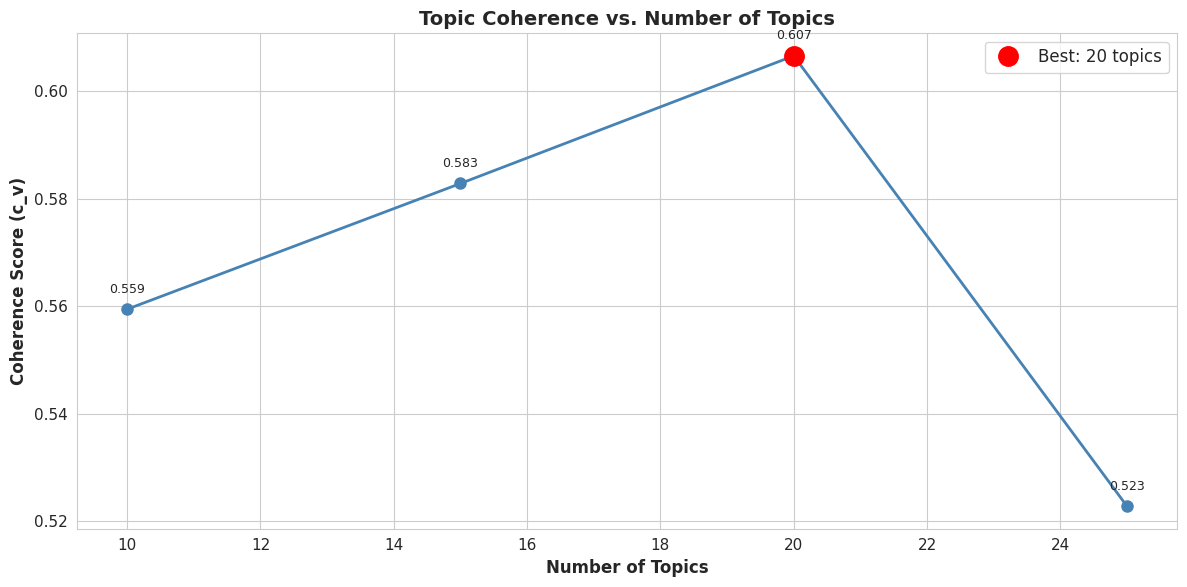

Saved: 01_coherence_scores.png


In [7]:
cls_lda.plot_coherence_scores(lst_topic_counts, lst_coherence_scores)

## Tune Hyperparameters

In [8]:
dict_best_params = cls_lda.tune_hyperparameters(int_n_trials=int_n_trials)


Tuning hyperparameters with 5 Optuna trials...


Optuna tuning: 100%|██████████| 5/5 [09:22<00:00, 112.58s/it, coherence=0.5500]


Best trial:
  Coherence: 0.6100
  Params: {'alpha': 0.08350779181790391, 'eta': 0.11206690568732684, 'passes': 5}


## Train Final Model

In [9]:
cls_lda.train_final_model(dict_best_params)


Training final LDA model with 20 topics...
Final model coherence (c_v): 0.5936


## Visualize Results

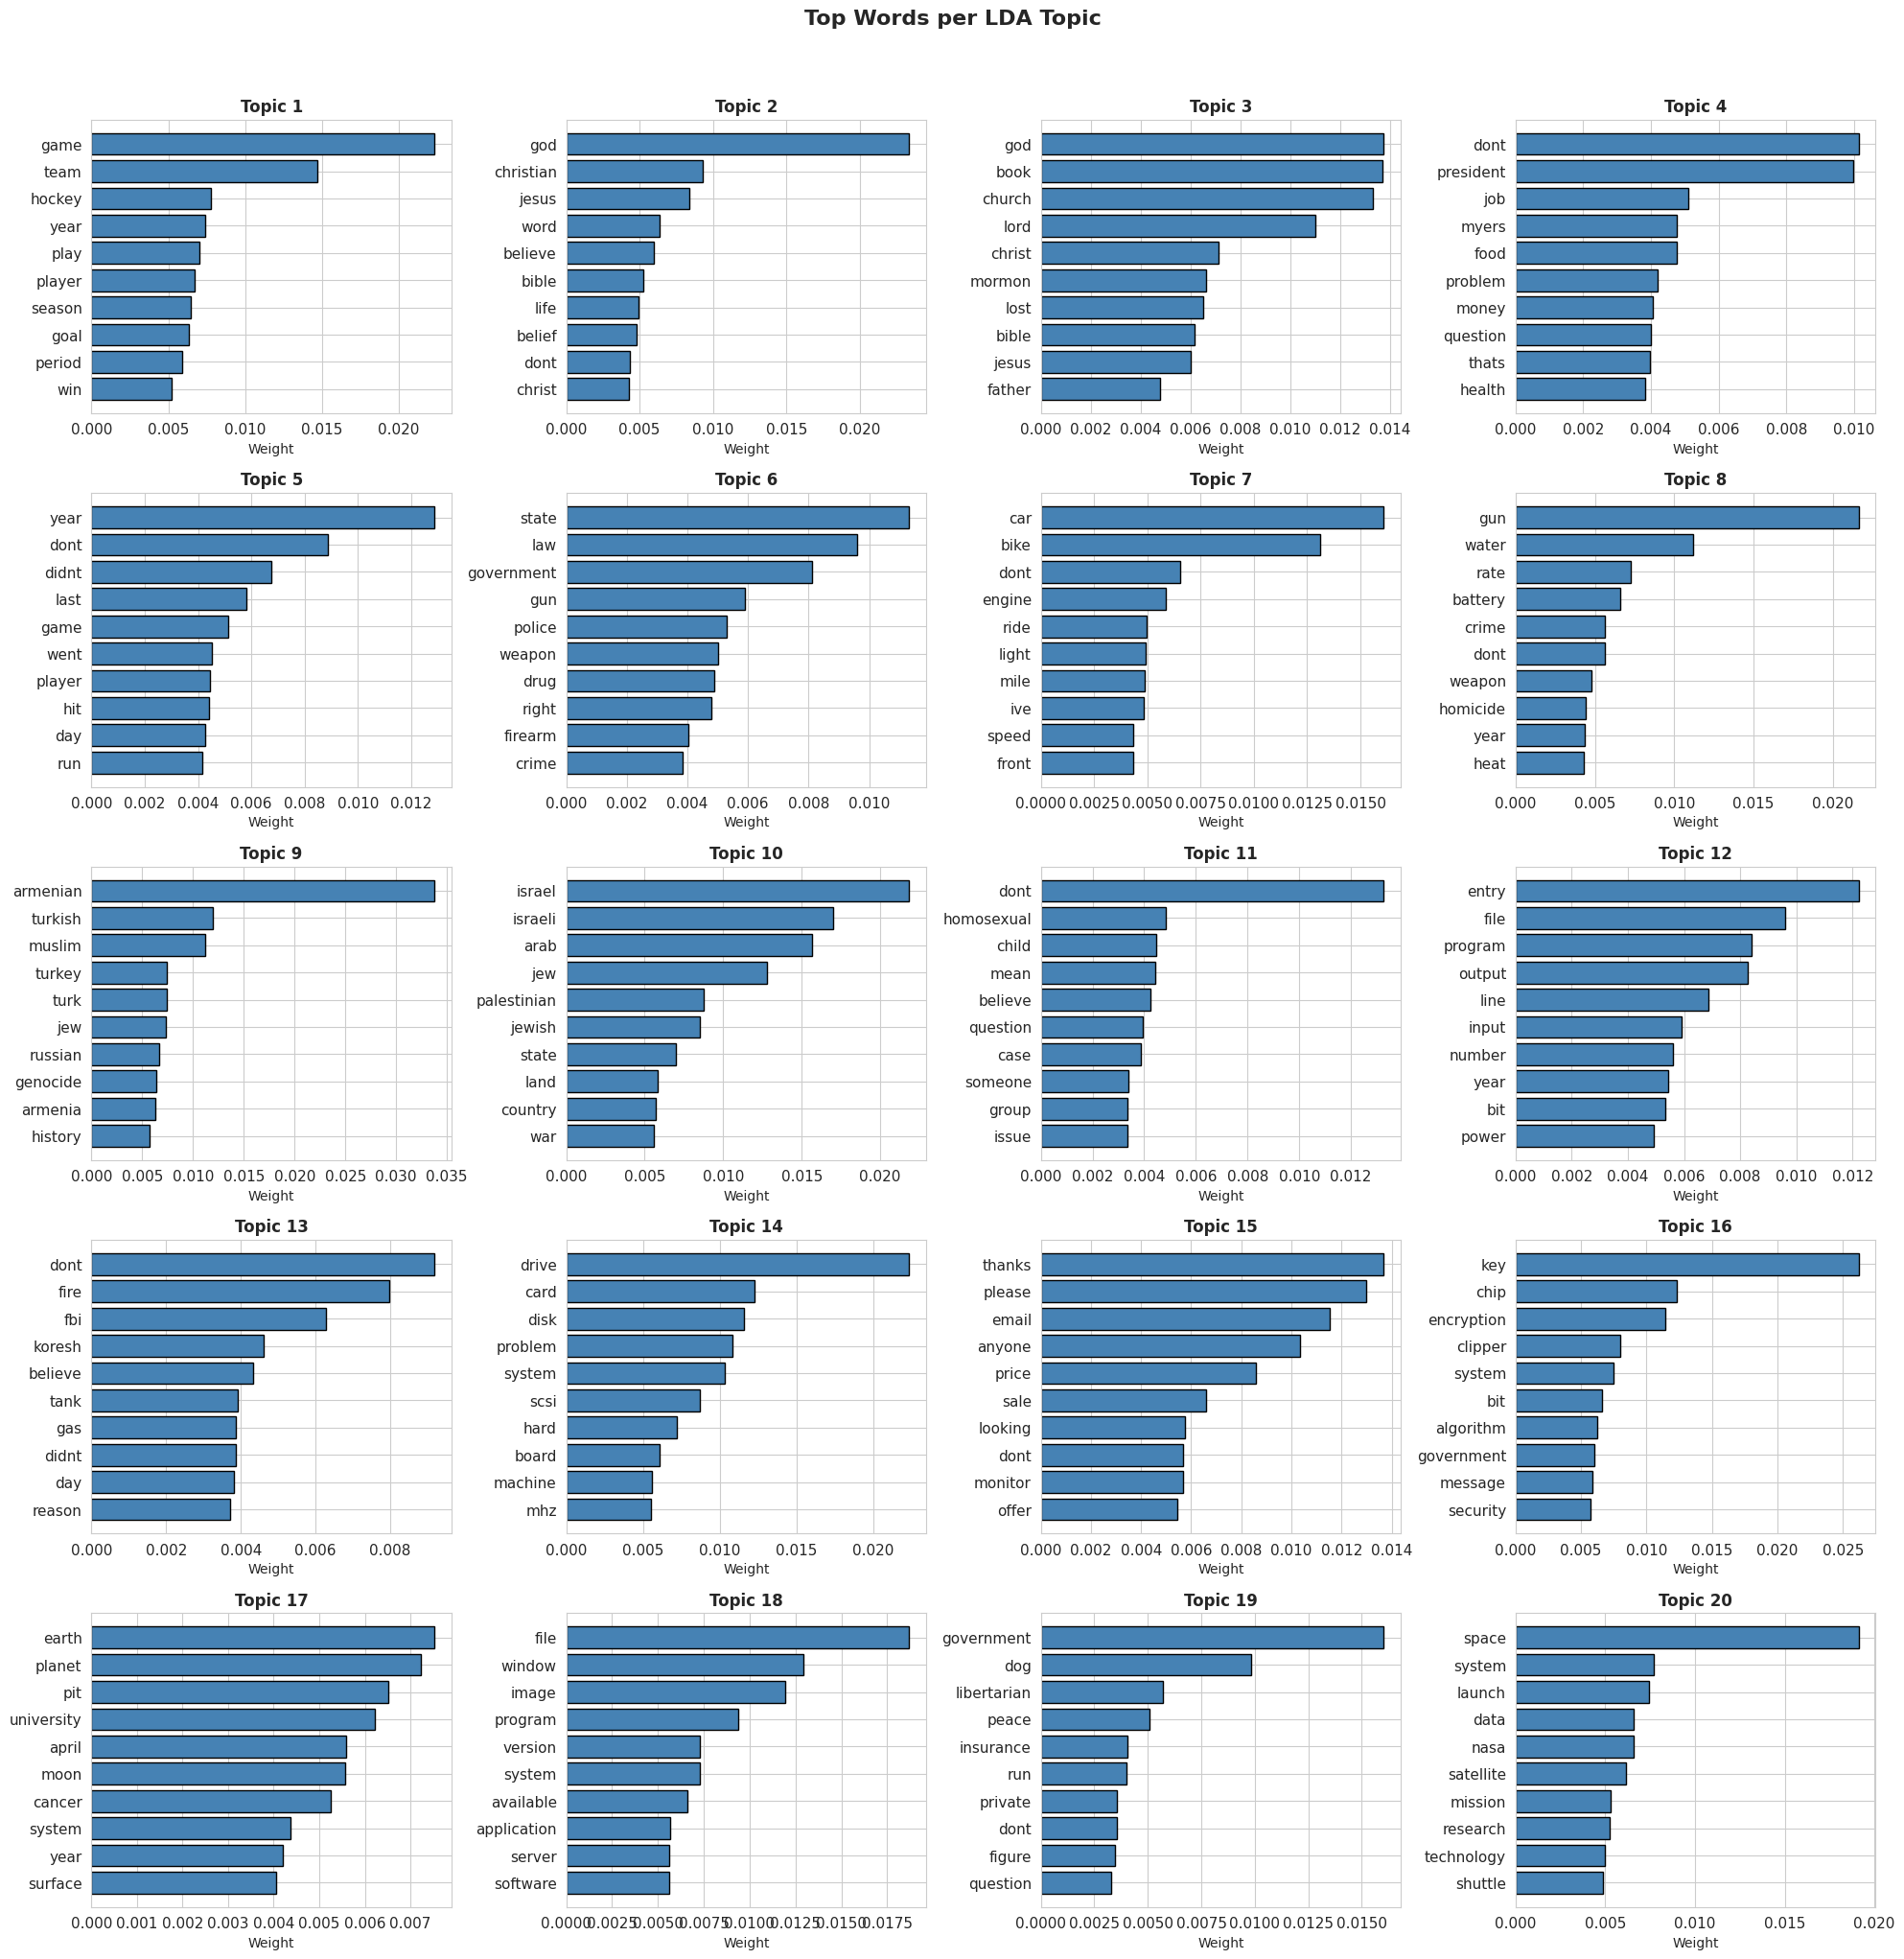

Saved: 02_top_words_per_topic.png


In [10]:
cls_lda.plot_top_words_per_topic()

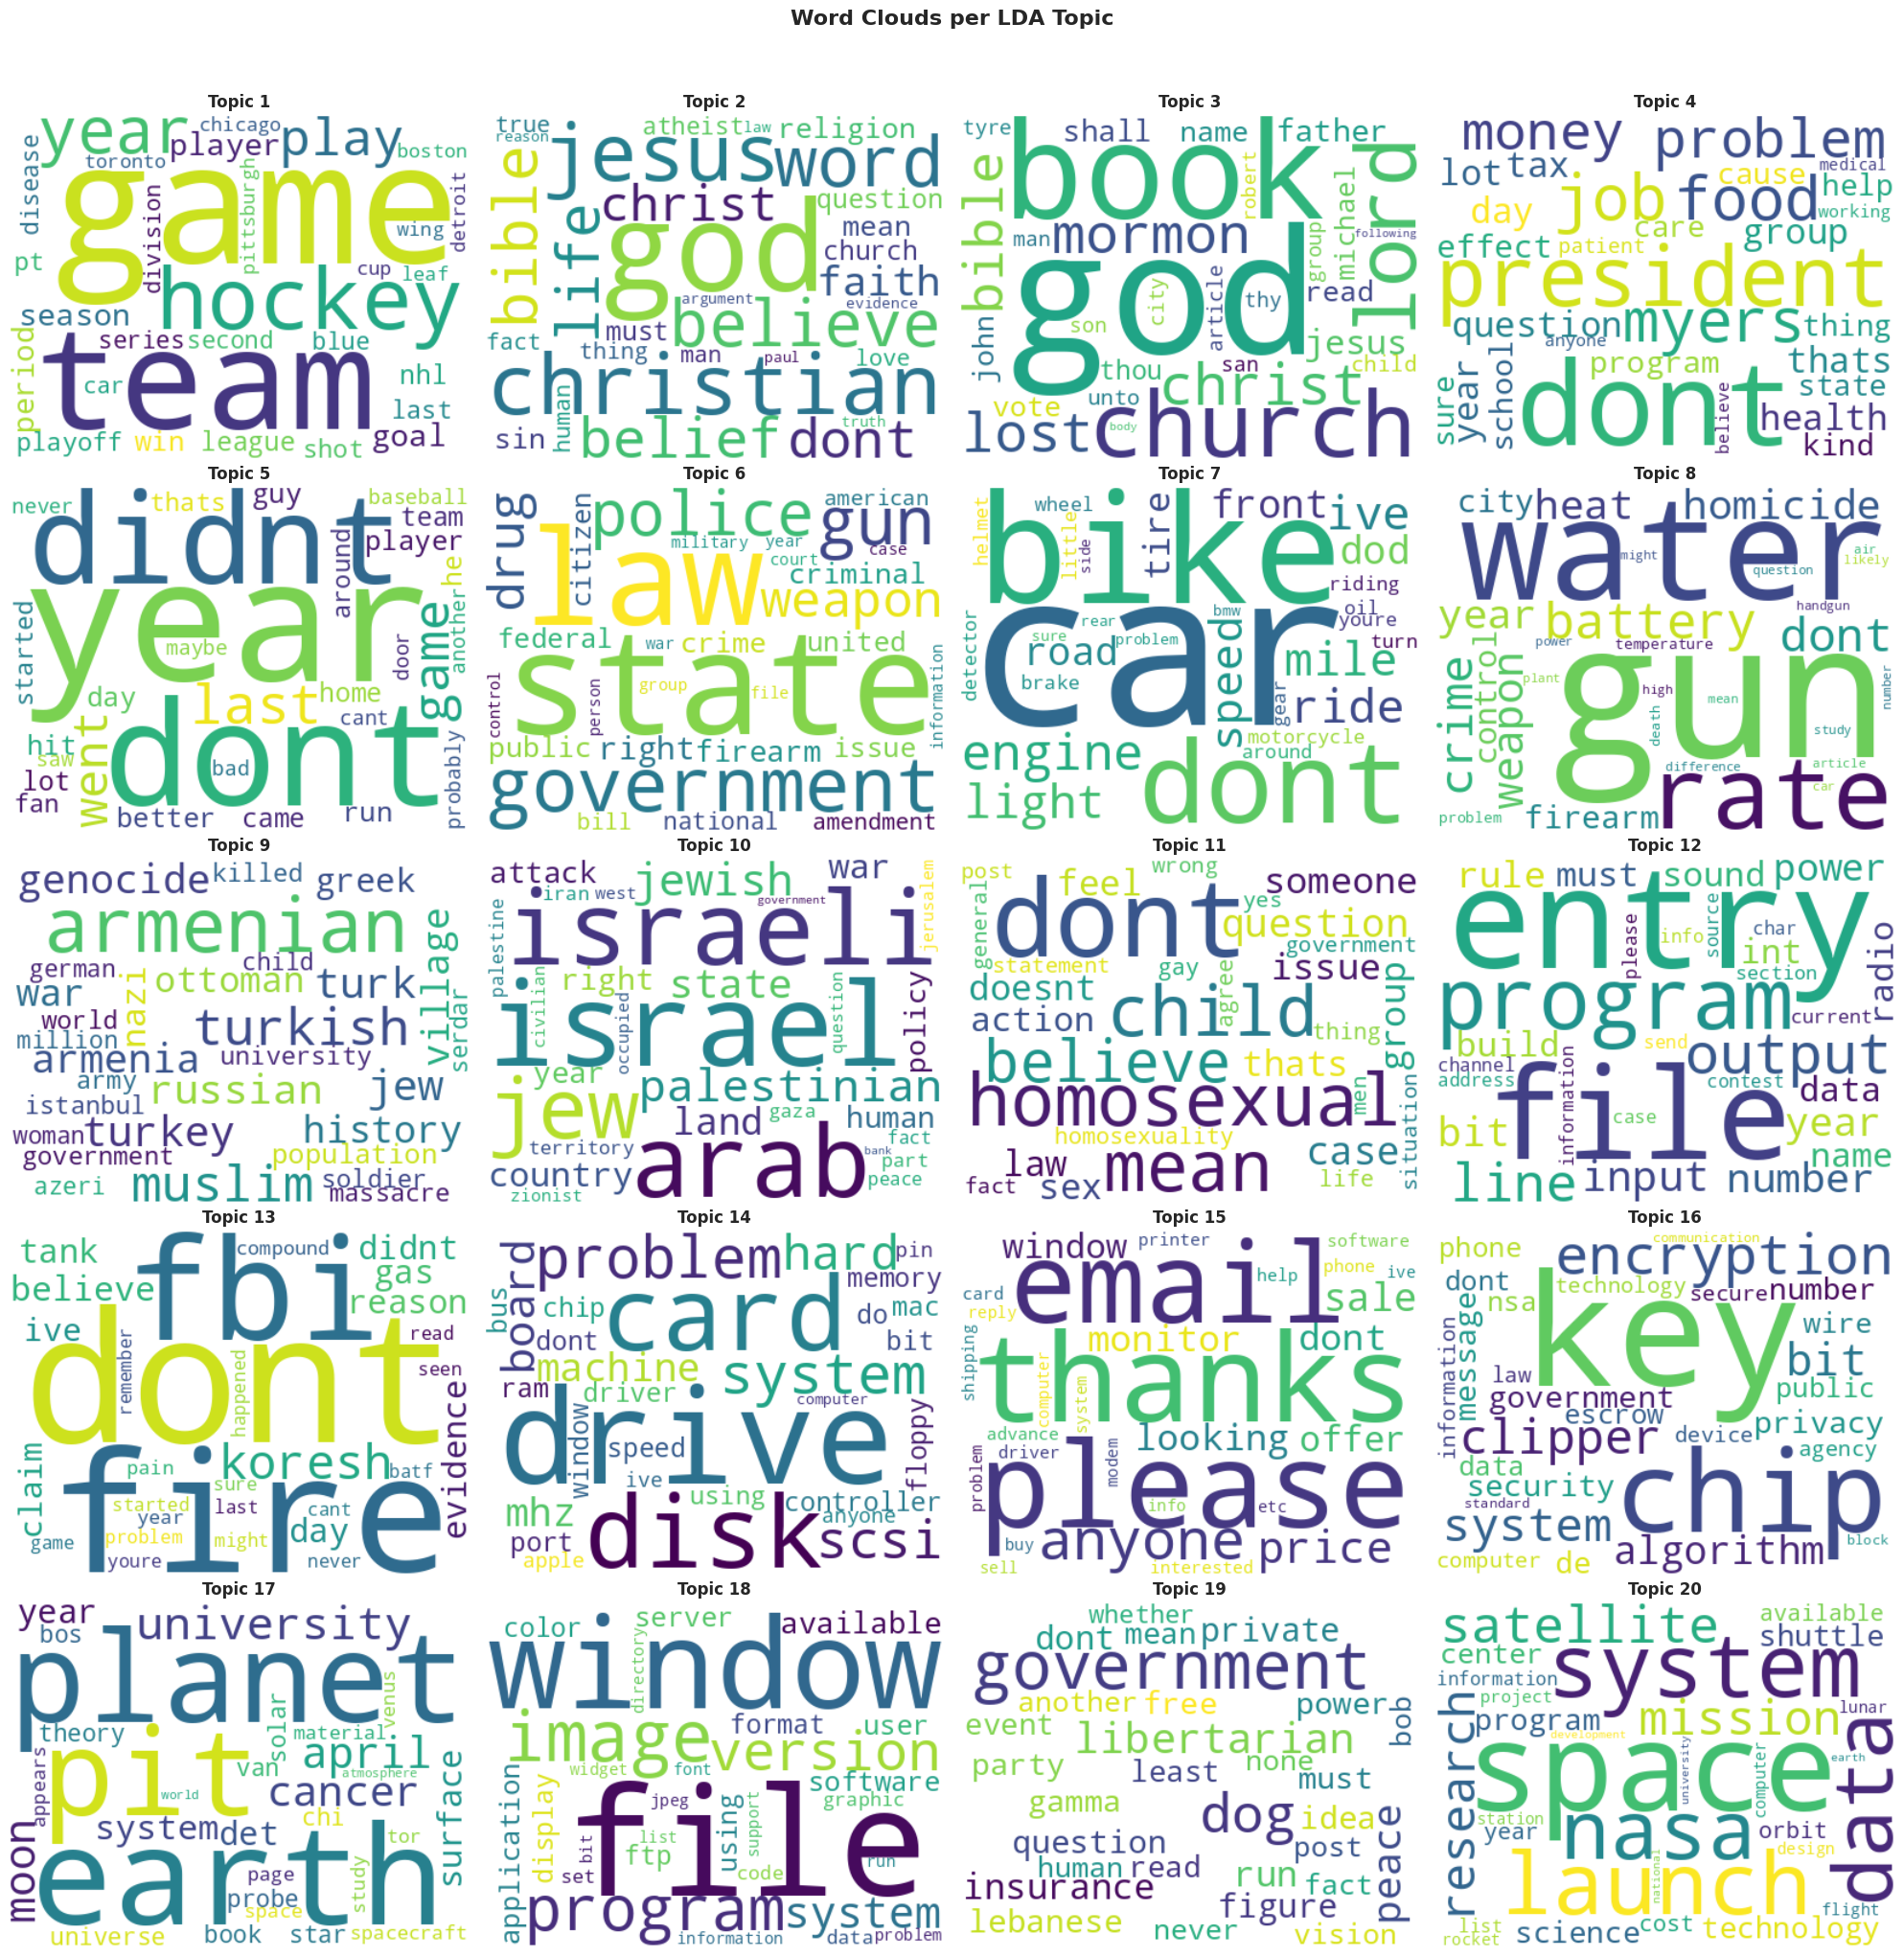

Saved: 03_word_clouds.png


In [11]:
cls_lda.plot_word_clouds()

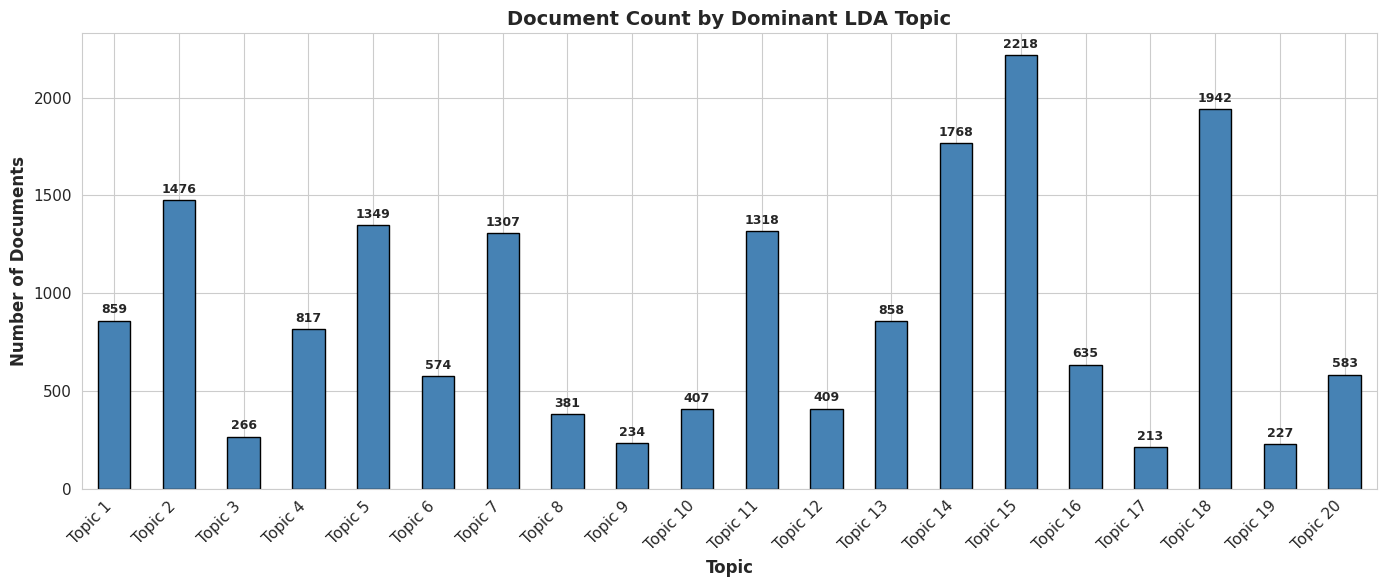

Saved: 04_topic_distribution.png


In [12]:
cls_lda.plot_topic_distribution()

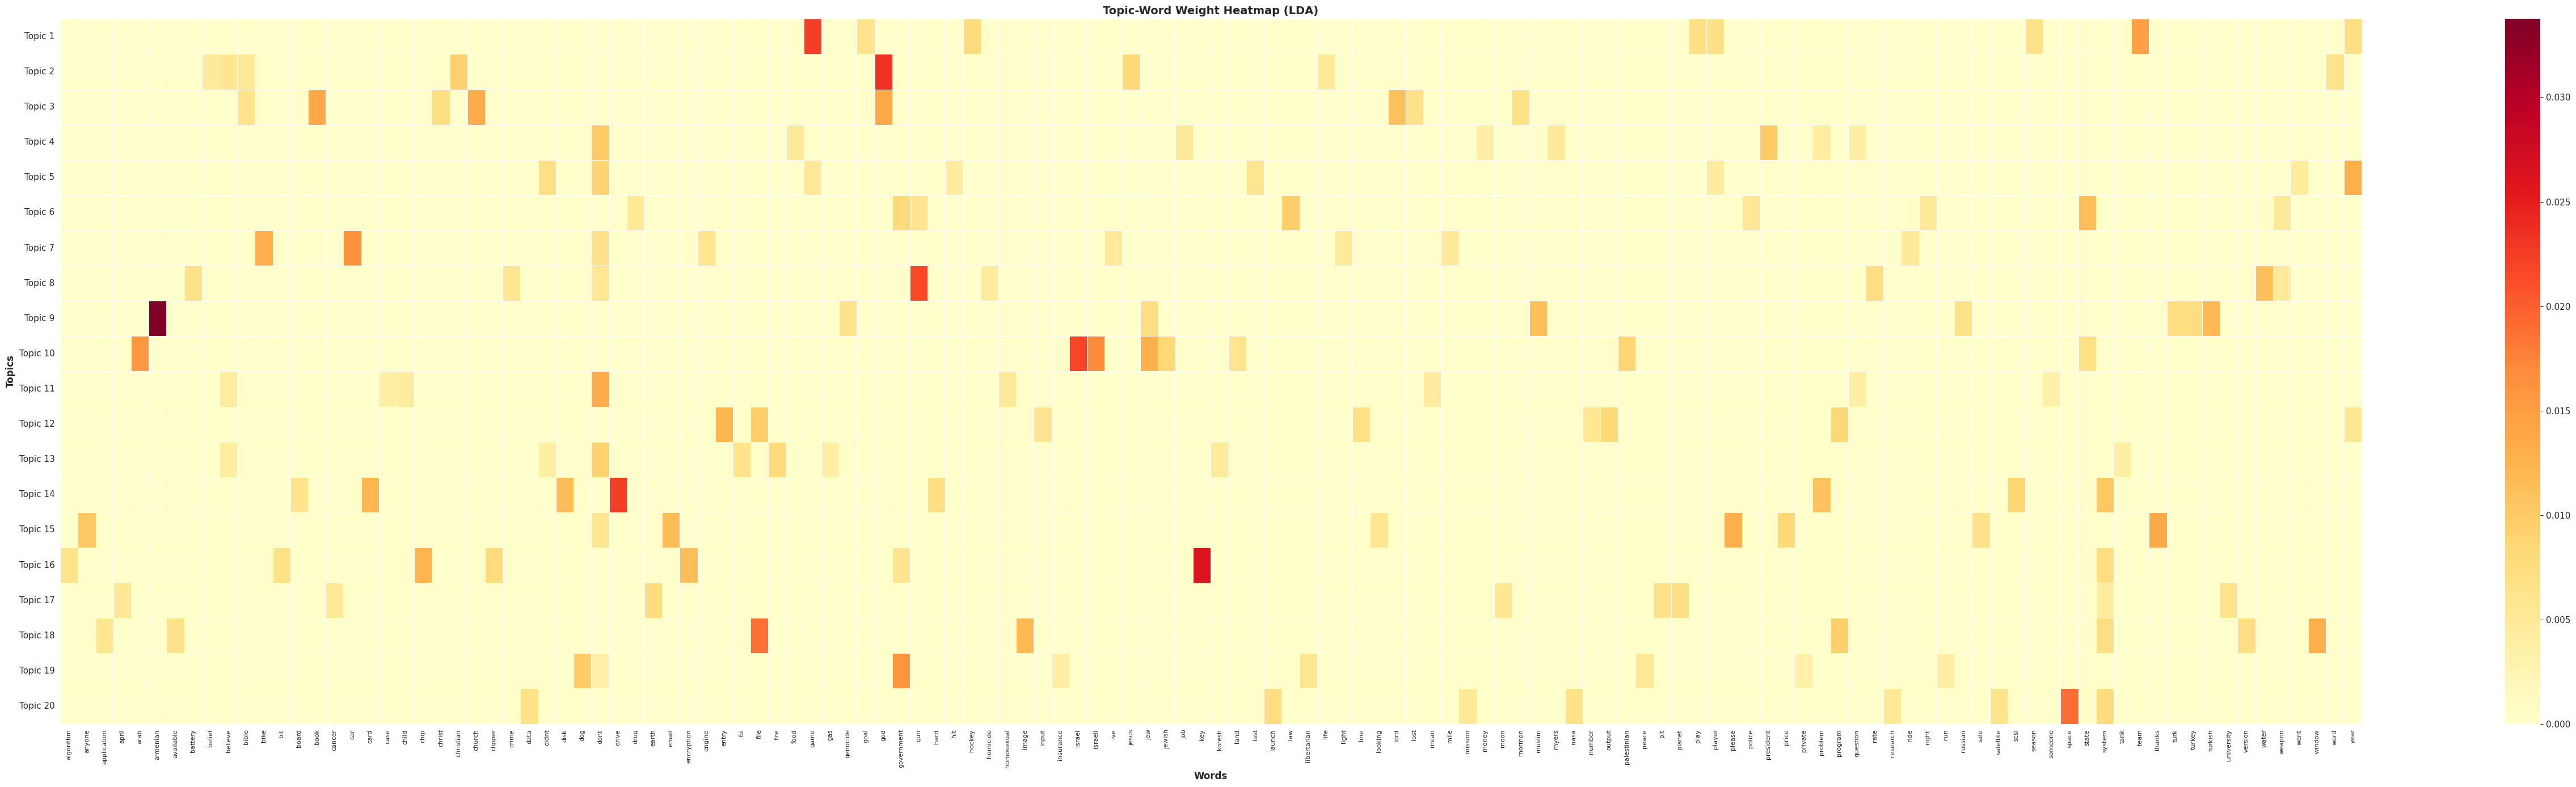

Saved: 05_topic_heatmap.png


In [13]:
cls_lda.plot_topic_heatmap()

## Save Model and Print Summary

In [14]:
cls_lda.save_model()

Model saved to ./output/lda_model.pkl


In [15]:
cls_lda.print_topics()


LDA TOPICS

Topic 1: game, team, hockey, year, play, player, season, goal, period, win

Topic 2: god, christian, jesus, word, believe, bible, life, belief, dont, christ

Topic 3: god, book, church, lord, christ, mormon, lost, bible, jesus, father

Topic 4: dont, president, job, myers, food, problem, money, question, thats, health

Topic 5: year, dont, didnt, last, game, went, player, hit, day, run

Topic 6: state, law, government, gun, police, weapon, drug, right, firearm, crime

Topic 7: car, bike, dont, engine, ride, light, mile, ive, speed, front

Topic 8: gun, water, rate, battery, crime, dont, weapon, homicide, year, heat

Topic 9: armenian, turkish, muslim, turkey, turk, jew, russian, genocide, armenia, history

Topic 10: israel, israeli, arab, jew, palestinian, jewish, state, land, country, war

Topic 11: dont, homosexual, child, mean, believe, question, case, someone, group, issue

Topic 12: entry, file, program, output, line, input, number, year, bit, power

Topic 13: dont, f